In [1]:
import numpy as np
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/data-scraping-thesis-concated-data-cut/Data Scraping Thesis - Concated Data Cut.csv')

In [3]:
df['Final Label'].value_counts()

Final Label
Non-Negatif             8795
Provokasi               5302
Penghinaan              1135
Pornografi              1014
Negatif Lainnya          609
SARA                     511
Pencemaran Nama Baik     158
Name: count, dtype: int64

In [4]:
def remove_punctuation_but_keep_emoticons(text):
    # Hapus karakter selain huruf, angka, spasi, dan rentang Unicode emotikon
    return re.sub(r'[^\w\s\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF\U00002702-\U000027B0\U0001F004-\U0001F0CF]', ' ', text)

def cleansing(df):
    df_clean = df.str.lower()  # Ubah semua teks menjadi huruf kecil
    df_clean = [re.sub(r"\d+", "", i) for i in df_clean]  # Hapus angka
    df_clean = [re.sub(r'http[s]?://\S+|www\.\S+', '', i) for i in df_clean]  # Hapus URL
    df_clean = [re.sub(r'@\S+', '', i) for i in df_clean]  # Hapus mention @username
    df_clean = [remove_punctuation_but_keep_emoticons(i) for i in df_clean]
    df_clean = [re.sub(r'\s+', ' ', i) for i in df_clean]  # Ganti spasi berlebih dengan satu spasi
    df_clean = [re.sub(r'(.)\1{2,}', r'\1\1', i) for i in df_clean]
    return df_clean

In [5]:
df['clean_text'] = cleansing(df['Comments'])

In [6]:
df.head()

,Comments,Final Label,clean_text
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,review nasi goreng ca dong dulu sih mangkal de...
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass kasih paham😁
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,ada harga k kmrn ada yg post tapi lupa dimana ...
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalo dah dewasa banget pengen ke msbreew...


In [7]:
abbr_dict = {
    "gk":"ga",
    "gx":"ga",
    "nggak":"ga",
    "gak":"ga",
    "kk":"kakak",
    "yg":"yang",
    "udh":"sudah",
    "udah":"sudah",
    "gw":"gue",
    "lo":"lu",
    "tp":"tapi",
    "lg":"lagi",
    "sm":"sama",
    "klo":"kalau",
    "klw":"kalau",
    "kalo":"kalau",
    "org":"orang",
    "w":"gue",
    "ku":"aku",
    "bru":"baru",
    "bgt":"banget",
    "si":"sih",
    "knp":"kenapa",
    "ato":"atau",
    "ky":"kaya",
    "bgst":"bangsat",
    "ajg":"anjing",
    "bg":"bang",
    "smg":"semoga"
}

In [8]:
def normalize_abbr(text, abbr_dict):
    pattern = r'\b(' + '|'.join(map(re.escape, abbr_dict.keys())) + r')\b'
    return re.sub(pattern, lambda x: abbr_dict[x.group()], text)

In [9]:
df['normalized_text'] = df['clean_text'].apply(lambda x: normalize_abbr(x.lower(), abbr_dict))

In [10]:
df.head()

,Comments,Final Label,clean_text,normalized_text
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...,orang seperti ini biasa nya di kasih seneng du...
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,review nasi goreng ca dong dulu sih mangkal de...,review nasi goreng ca dong dulu sih mangkal de...
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass kasih paham😁,🤣🤣senggol bib gass kasih paham😁
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,ada harga k kmrn ada yg post tapi lupa dimana ...,ada harga k kmrn ada yang post tapi lupa diman...
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalo dah dewasa banget pengen ke msbreew...,nanti kalau dah dewasa banget pengen ke msbree...


In [11]:
from nltk.tokenize import word_tokenize

df['tokenized_text'] = df['normalized_text'].apply(lambda x: word_tokenize(x))

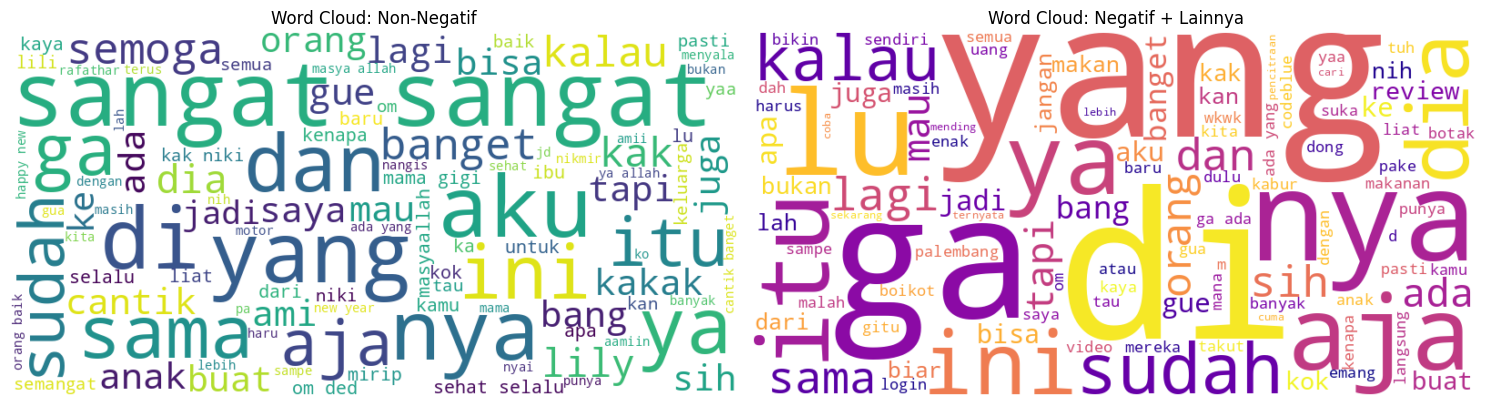

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Filter data untuk label 'Non-Negatif'
non_negatif_data = df[df['Final Label'] == 'Non-Negatif']

# 2. Gabungkan teks-teks untuk label 'Non-Negatif'
non_negatif_text = " ".join(non_negatif_data['normalized_text'])

# 3. Filter data untuk label selain 'Non-Negatif' (Misalnya untuk 'Negatif' dan label lainnya)
negatif_data = df[df['Final Label'] != 'Non-Negatif']

# 4. Gabungkan teks-teks untuk label selain 'Non-Negatif'
negatif_text = " ".join(negatif_data['normalized_text'])

# 5. Word Cloud untuk label 'Non-Negatif'
wordcloud_non_negatif = WordCloud(width=800, height=400, background_color="white", colormap="viridis",
                                   max_words=100, contour_width=3, contour_color="steelblue").generate(non_negatif_text)

# 6. Word Cloud untuk label selain 'Non-Negatif' (Negatif + Lainnya)
wordcloud_negatif = WordCloud(width=800, height=400, background_color="white", colormap="plasma",
                              max_words=100, contour_width=3, contour_color="steelblue").generate(negatif_text)

# 7. Tampilkan kedua Word Cloud
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Tampilkan Word Cloud untuk Non-Negatif
axes[0].imshow(wordcloud_non_negatif, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Word Cloud: Non-Negatif")

# Tampilkan Word Cloud untuk label selain Non-Negatif
axes[1].imshow(wordcloud_negatif, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud: Negatif + Lainnya")

plt.tight_layout()
plt.show()

In [13]:
def clean_tokens(tokens):
    cleaned = []
    for t in tokens:
        if len(t) > 3:                   # buang kata <= 3 huruf
            cleaned.append(t)
    return cleaned

In [14]:
df['tokenized_text_clean'] = df['tokenized_text'].apply(clean_tokens)

In [15]:
df.head()

,Comments,Final Label,clean_text,normalized_text,tokenized_text,tokenized_text_clean
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...,orang seperti ini biasa nya di kasih seneng du...,"[orang, seperti, ini, biasa, nya, di, kasih, s...","[orang, seperti, biasa, kasih, seneng, dulu, b..."
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,review nasi goreng ca dong dulu sih mangkal de...,review nasi goreng ca dong dulu sih mangkal de...,"[review, nasi, goreng, ca, dong, dulu, sih, ma...","[review, nasi, goreng, dong, dulu, mangkal, de..."
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass kasih paham😁,🤣🤣senggol bib gass kasih paham😁,"[🤣🤣senggol, bib, gass, kasih, paham😁]","[🤣🤣senggol, gass, kasih, paham😁]"
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,ada harga k kmrn ada yg post tapi lupa dimana ...,ada harga k kmrn ada yang post tapi lupa diman...,"[ada, harga, k, kmrn, ada, yang, post, tapi, l...","[harga, kmrn, yang, post, tapi, lupa, dimana, ..."
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalo dah dewasa banget pengen ke msbreew...,nanti kalau dah dewasa banget pengen ke msbree...,"[nanti, kalau, dah, dewasa, banget, pengen, ke...","[nanti, kalau, dewasa, banget, pengen, msbreewc]"


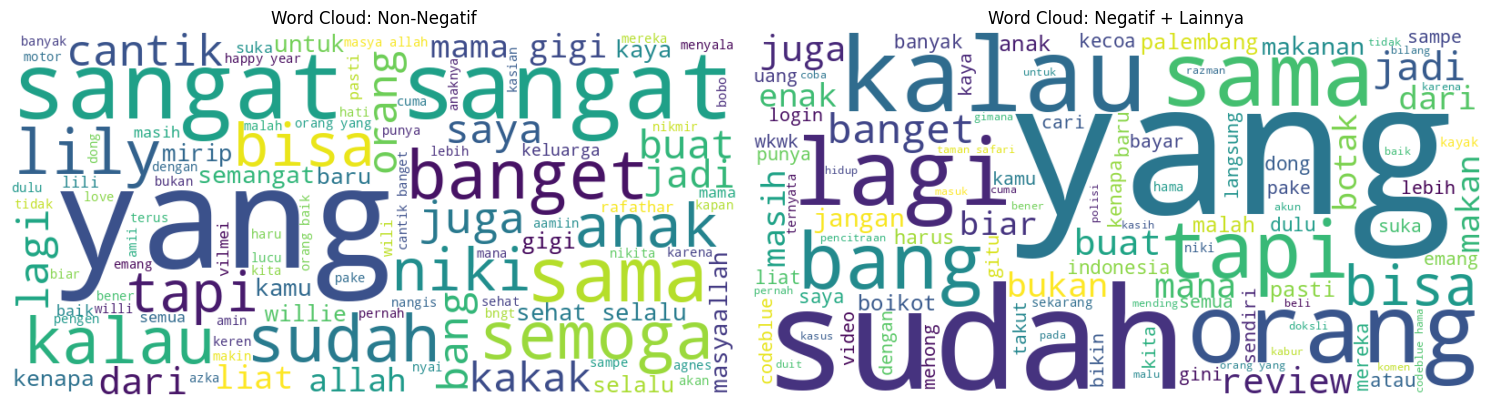

In [16]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter data
non_negatif_data = df[df['Final Label'] == 'Non-Negatif']
negatif_data = df[df['Final Label'] != 'Non-Negatif']

# Gabungkan token jadi text
non_negatif_text = " ".join(
    non_negatif_data['tokenized_text_clean'].apply(lambda x: " ".join(x))
)

negatif_text = " ".join(
    negatif_data['tokenized_text_clean'].apply(lambda x: " ".join(x))
)

# WordCloud
wordcloud_non_negatif = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(non_negatif_text)

wordcloud_negatif = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(negatif_text)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].imshow(wordcloud_non_negatif, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Word Cloud: Non-Negatif")

axes[1].imshow(wordcloud_negatif, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud: Negatif + Lainnya")

plt.tight_layout()
plt.show()

In [17]:
from nltk.corpus import stopwords

list_stopwords = set(stopwords.words('indonesian'))
df['without_stopwords'] = df['tokenized_text_clean'].apply(lambda tokens: [word for word in tokens if word not in list_stopwords])

In [18]:
df['cleaned_comments'] = df['without_stopwords'].apply(lambda tokens: " ".join(tokens))

In [19]:
df.head()

,Comments,Final Label,clean_text,normalized_text,tokenized_text,tokenized_text_clean,without_stopwords,cleaned_comments
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...,orang seperti ini biasa nya di kasih seneng du...,"[orang, seperti, ini, biasa, nya, di, kasih, s...","[orang, seperti, biasa, kasih, seneng, dulu, b...","[orang, kasih, seneng, biar, puas, kena]",orang kasih seneng biar puas kena
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,review nasi goreng ca dong dulu sih mangkal de...,review nasi goreng ca dong dulu sih mangkal de...,"[review, nasi, goreng, ca, dong, dulu, sih, ma...","[review, nasi, goreng, dong, dulu, mangkal, de...","[review, nasi, goreng, mangkal, poslim]",review nasi goreng mangkal poslim
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass kasih paham😁,🤣🤣senggol bib gass kasih paham😁,"[🤣🤣senggol, bib, gass, kasih, paham😁]","[🤣🤣senggol, gass, kasih, paham😁]","[🤣🤣senggol, gass, kasih, paham😁]",🤣🤣senggol gass kasih paham😁
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,ada harga k kmrn ada yg post tapi lupa dimana ...,ada harga k kmrn ada yang post tapi lupa diman...,"[ada, harga, k, kmrn, ada, yang, post, tapi, l...","[harga, kmrn, yang, post, tapi, lupa, dimana, ...","[harga, kmrn, post, lupa, dimana, tempatnyaa]",harga kmrn post lupa dimana tempatnyaa
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalo dah dewasa banget pengen ke msbreew...,nanti kalau dah dewasa banget pengen ke msbree...,"[nanti, kalau, dah, dewasa, banget, pengen, ke...","[nanti, kalau, dewasa, banget, pengen, msbreewc]","[dewasa, banget, pengen, msbreewc]",dewasa banget pengen msbreewc


## Stanza

In [20]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 39.6 MB/s eta 0:00:00


In [21]:
import stanza
stanza.download('id')

2026-02-15 16:22:05 INFO: Downloaded file to /root/stanza_resources/resources.json
2026-02-15 16:22:05 INFO: Downloading default packages for language: id (Indonesian) ...


2026-02-15 16:22:14 INFO: Downloaded file to /root/stanza_resources/id/default.zip
2026-02-15 16:22:18 INFO: Finished downloading models and saved to /root/stanza_resources


In [22]:
import stanza

nlp = stanza.Pipeline(
    lang='id',
    processors='tokenize,pos,lemma',
    tokenize_no_ssplit=True
)

2026-02-15 16:22:18 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-02-15 16:22:19 INFO: Downloaded file to /root/stanza_resources/resources.json
2026-02-15 16:22:19 WARNING: Language id package default expects mwt, which has been added
2026-02-15 16:22:19 INFO: Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |

2026-02-15 16:22:19 INFO: Using device: cpu
2026-02-15 16:22:19 INFO: Loading: tokenize
2026-02-15 16:22:25 INFO: Loading: mwt
2026-02-15 16:22:25 INFO: Loading: pos
2026-02-15 16:22:28 INFO: Loading: lemma
2026-02-15 16:22:28 INFO: Done loading processors!


In [23]:
def stanza(text):
    doc = nlp(text)
    tokens = []
    for sent in doc.sentences:
        for w in sent.words:
            tokens.append(w.lemma)
    return " ".join(tokens)

In [24]:
df['lemma_stanza'] = df['cleaned_comments'].apply(stanza)

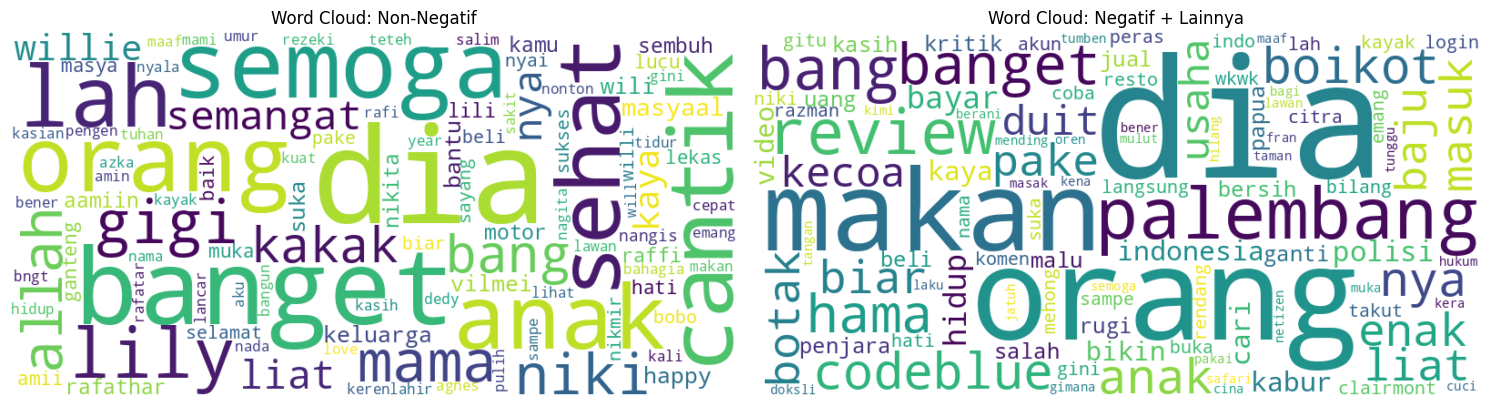

In [25]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter data
non_negatif_data = df[df['Final Label'] == 'Non-Negatif']
negatif_data = df[df['Final Label'] != 'Non-Negatif']

# Fungsi aman: handle list atau string
def join_text(x):
    if isinstance(x, list):
        return " ".join(x)
    return x

# Gabungkan semua text jadi satu string
non_negatif_text = " ".join(
    non_negatif_data['lemma_stanza'].apply(join_text)
)

negatif_text = " ".join(
    negatif_data['lemma_stanza'].apply(join_text)
)

# WordCloud
wordcloud_non_negatif = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    collocations=False
).generate(non_negatif_text)

wordcloud_negatif = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    collocations=False
).generate(negatif_text)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(wordcloud_non_negatif, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Word Cloud: Non-Negatif")

axes[1].imshow(wordcloud_negatif, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud: Negatif + Lainnya")

plt.tight_layout()
plt.show()

In [26]:
df.head()

,Comments,Final Label,clean_text,normalized_text,tokenized_text,tokenized_text_clean,without_stopwords,cleaned_comments,lemma_stanza
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...,orang seperti ini biasa nya di kasih seneng du...,"[orang, seperti, ini, biasa, nya, di, kasih, s...","[orang, seperti, biasa, kasih, seneng, dulu, b...","[orang, kasih, seneng, biar, puas, kena]",orang kasih seneng biar puas kena,orang kasih seneng biar puas kena
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,review nasi goreng ca dong dulu sih mangkal de...,review nasi goreng ca dong dulu sih mangkal de...,"[review, nasi, goreng, ca, dong, dulu, sih, ma...","[review, nasi, goreng, dong, dulu, mangkal, de...","[review, nasi, goreng, mangkal, poslim]",review nasi goreng mangkal poslim,review nasi goreng mangkal poslim
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass kasih paham😁,🤣🤣senggol bib gass kasih paham😁,"[🤣🤣senggol, bib, gass, kasih, paham😁]","[🤣🤣senggol, gass, kasih, paham😁]","[🤣🤣senggol, gass, kasih, paham😁]",🤣🤣senggol gass kasih paham😁,🤣🤣senggol gass kasih paham 😁
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,ada harga k kmrn ada yg post tapi lupa dimana ...,ada harga k kmrn ada yang post tapi lupa diman...,"[ada, harga, k, kmrn, ada, yang, post, tapi, l...","[harga, kmrn, yang, post, tapi, lupa, dimana, ...","[harga, kmrn, post, lupa, dimana, tempatnyaa]",harga kmrn post lupa dimana tempatnyaa,harga kmrn post lupa dimana tempatnyaa
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalo dah dewasa banget pengen ke msbreew...,nanti kalau dah dewasa banget pengen ke msbree...,"[nanti, kalau, dah, dewasa, banget, pengen, ke...","[nanti, kalau, dewasa, banget, pengen, msbreewc]","[dewasa, banget, pengen, msbreewc]",dewasa banget pengen msbreewc,dewasa banget pengen msbreewc


### Data Splitting

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, log_loss
from sklearn.metrics import classification_report, confusion_matrix

In [28]:
x_train_stanza, x_test_stanza, y_train_stanza, y_test_stanza = train_test_split(df['lemma_stanza'], df['Final Label'], test_size = 0.2, random_state = 42,stratify=df['Final Label'])

## RANDOM FOREST - 1 STAGE

## TF-IDF & RF - Default

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
vectorizer = TfidfVectorizer()
train_tfidf= vectorizer.fit_transform(x_train_stanza)
test_tfidf = vectorizer.transform(x_test_stanza)

In [31]:
TFIDF_train=pd.DataFrame(train_tfidf.toarray(),columns=vectorizer.get_feature_names_out())
TFIDF_train.head()

,aacchh,aah,aahh,aal,aamii,aamiim,aamiin,aamiinn,aamin,aammiin,...,𝙢𝙪𝙙𝙞𝙠,𝙥𝙞𝙣𝙟𝙚𝙢,𝙪𝙖𝙣𝙜,𝚂𝚊𝚔𝚒𝚗𝚐,𝚋𝚊𝚓𝚞,𝚌𝚊𝚙𝚎,𝚕𝚞𝚙𝚊,𝚙𝚊𝚔𝚎,𝚚𝚒𝚖,𝚜𝚊𝚖𝚙𝚎
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
train_tfidf.shape

(14019, 10135)

In [33]:
TFIDF_test = pd.DataFrame(test_tfidf.toarray(),columns=vectorizer.get_feature_names_out())
TFIDF_test.head()

,aacchh,aah,aahh,aal,aamii,aamiim,aamiin,aamiinn,aamin,aammiin,...,𝙢𝙪𝙙𝙞𝙠,𝙥𝙞𝙣𝙟𝙚𝙢,𝙪𝙖𝙣𝙜,𝚂𝚊𝚔𝚒𝚗𝚐,𝚋𝚊𝚓𝚞,𝚌𝚊𝚙𝚎,𝚕𝚞𝚙𝚊,𝚙𝚊𝚔𝚎,𝚚𝚒𝚖,𝚜𝚊𝚖𝚙𝚎
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
from sklearn.ensemble import RandomForestClassifier
RF_Class = RandomForestClassifier()
RF_Class.fit(train_tfidf, y_train_stanza)

RandomForestClassifier()

In [35]:
test_rf_class = RF_Class.predict(test_tfidf)

In [36]:
import time

start_time = time.time()

test_rf_class = RF_Class.predict(test_tfidf)

end_time = time.time()

total_inference_time = end_time - start_time
num_samples = test_tfidf.shape[0]

time_per_sample = total_inference_time / num_samples

print("Total inference time:", total_inference_time, "seconds")
print("Number of samples:", num_samples)
print("Inference time per sample:", time_per_sample, "seconds")

Total inference time: 1.3732171058654785 seconds
Number of samples: 3505
Inference time per sample: 0.0003917880473225331 seconds


In [37]:
RF_lable = RF_Class.classes_

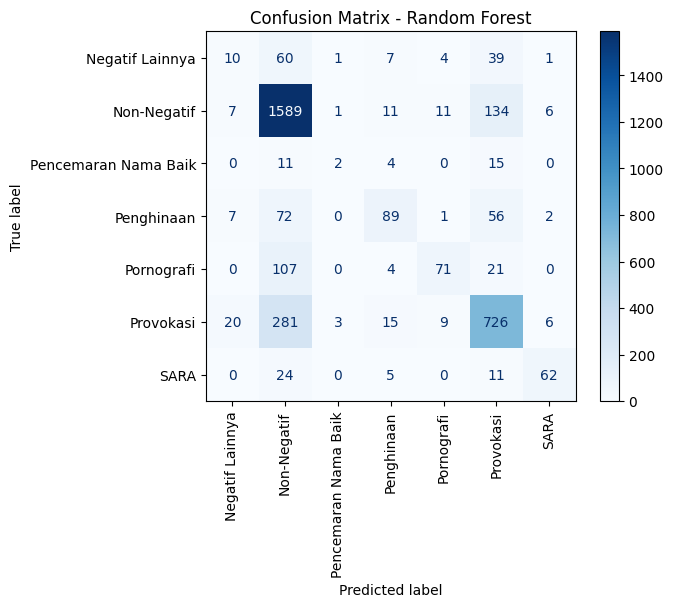

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_test_stanza,
    test_rf_class,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest")
plt.xticks(rotation=90)
plt.show()

In [39]:
print('\nClassification Report Random Forest\n')
print(classification_report(y_test_stanza, test_rf_class, target_names=RF_lable))


Classification Report Random Forest

                      precision    recall  f1-score   support

     Negatif Lainnya       0.23      0.08      0.12       122
         Non-Negatif       0.74      0.90      0.81      1759
Pencemaran Nama Baik       0.29      0.06      0.10        32
          Penghinaan       0.66      0.39      0.49       227
          Pornografi       0.74      0.35      0.47       203
           Provokasi       0.72      0.68      0.70      1060
                SARA       0.81      0.61      0.69       102

            accuracy                           0.73      3505
           macro avg       0.60      0.44      0.49      3505
        weighted avg       0.71      0.73      0.71      3505



In [40]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

In [41]:
y_score = RF_Class.predict_proba(test_tfidf)

In [42]:
classes = RF_Class.classes_
y_test_bin = label_binarize(y_test_stanza, classes=classes)

In [43]:
precision = {}
recall = {}
average_precision = {}

for i in range(len(classes)):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )
    average_precision[i] = average_precision_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

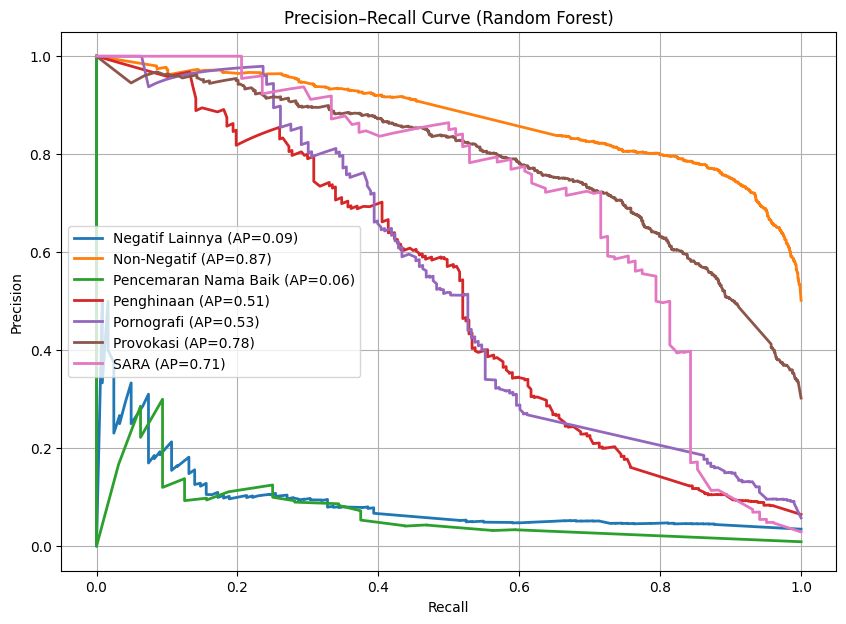

In [44]:
plt.figure(figsize=(10, 7))

for i, label in enumerate(classes):
    plt.plot(
        recall[i],
        precision[i],
        lw=2,
        label=f"{label} (AP={average_precision[i]:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Random Forest)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### TF-IDF & RF - Tuning

In [45]:
from sklearn.ensemble import RandomForestClassifier
RF_Class = RandomForestClassifier(n_estimators=200,
    class_weight='balanced')
RF_Class.fit(train_tfidf, y_train_stanza)

RandomForestClassifier(class_weight='balanced', n_estimators=200)

In [46]:
test_rf_class = RF_Class.predict(test_tfidf)

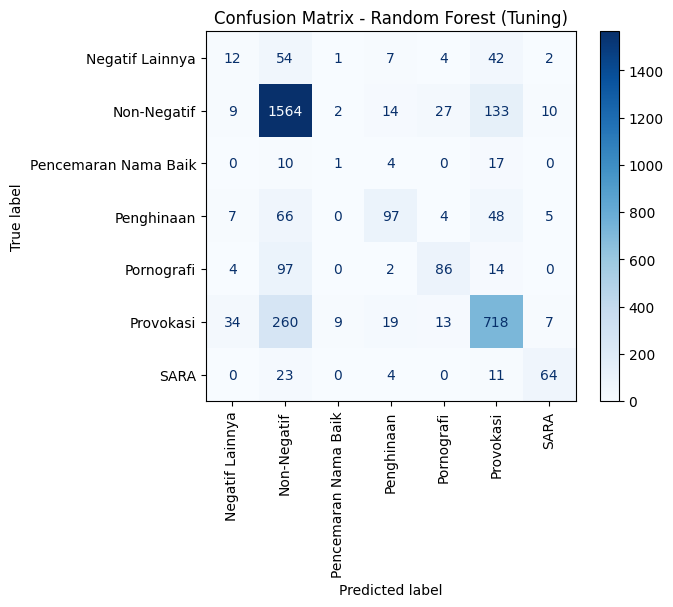

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_test_stanza,
    test_rf_class,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest (Tuning)")
plt.xticks(rotation=90)
plt.show()

In [48]:
print('\nClassification Report Random Forest\n')
print(classification_report(y_test_stanza, test_rf_class, target_names=RF_lable))


Classification Report Random Forest

                      precision    recall  f1-score   support

     Negatif Lainnya       0.18      0.10      0.13       122
         Non-Negatif       0.75      0.89      0.82      1759
Pencemaran Nama Baik       0.08      0.03      0.04        32
          Penghinaan       0.66      0.43      0.52       227
          Pornografi       0.64      0.42      0.51       203
           Provokasi       0.73      0.68      0.70      1060
                SARA       0.73      0.63      0.67       102

            accuracy                           0.73      3505
           macro avg       0.54      0.45      0.48      3505
        weighted avg       0.71      0.73      0.71      3505



In [49]:
y_score = RF_Class.predict_proba(test_tfidf)

In [50]:
precision = {}
recall = {}
average_precision = {}

for i in range(len(classes)):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )
    average_precision[i] = average_precision_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

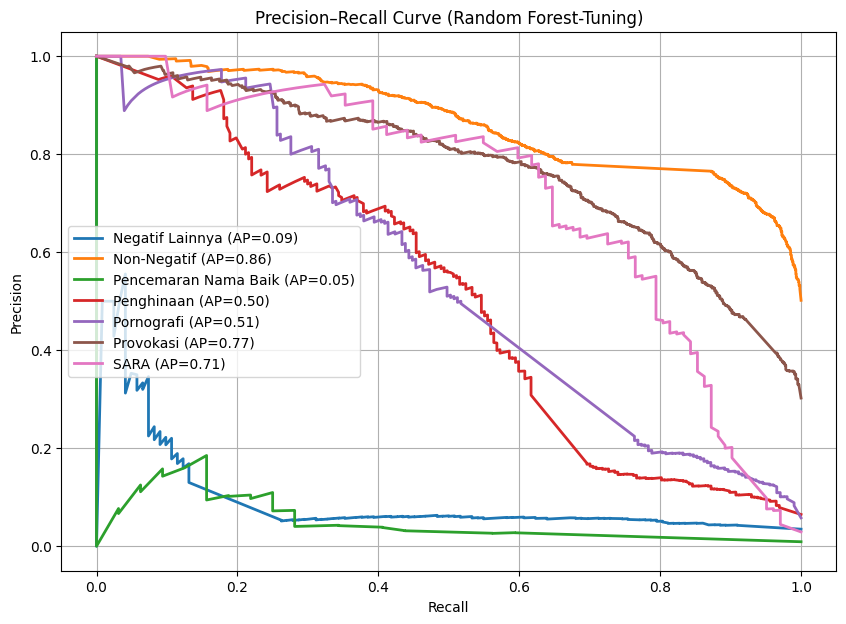

In [51]:
plt.figure(figsize=(10, 7))

for i, label in enumerate(classes):
    plt.plot(
        recall[i],
        precision[i],
        lw=2,
        label=f"{label} (AP={average_precision[i]:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Random Forest-Tuning)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## Word2Vec & RF - Default

In [52]:
x_train_tokens = [text.split() for text in x_train_stanza]
x_test_tokens  = [text.split() for text in x_test_stanza]

In [53]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=x_train_tokens,
    vector_size=100,   # dimensi embedding
    window=5,
    min_count=2,
    workers=4,
    sg=1              # 1 = skip-gram (umumnya lebih bagus)
)

/usr/local/lib/python3.12/dist-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


In [54]:
def document_vector(doc, model):
    vecs = []
    for word in doc:
        if word in model.wv:
            vecs.append(model.wv[word])
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

In [55]:
x_train_w2v = np.array([
    document_vector(doc, w2v_model)
    for doc in x_train_tokens
])

x_test_w2v = np.array([
    document_vector(doc, w2v_model)
    for doc in x_test_tokens
])

In [56]:
rf = RandomForestClassifier()

rf.fit(x_train_w2v, y_train_stanza)
y_pred = rf.predict(x_test_w2v)

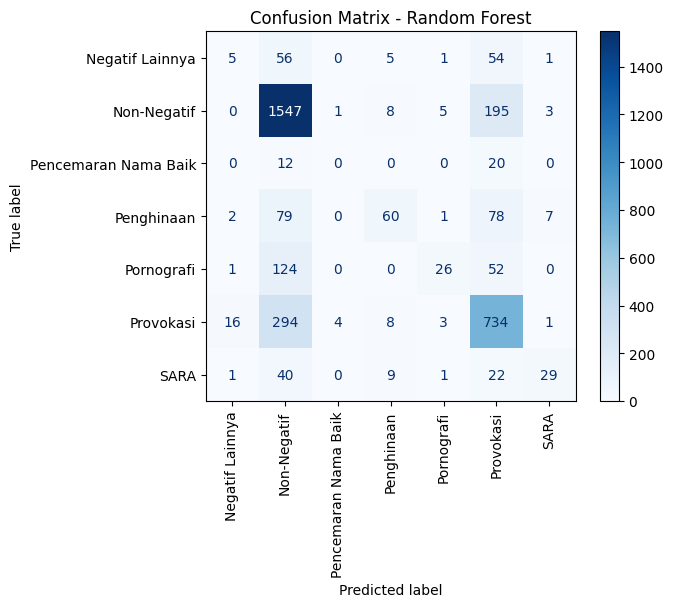

In [57]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_stanza,
    y_pred,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest")
plt.xticks(rotation=90)
plt.show()

In [58]:
RF_lable = rf.classes_

In [59]:
print('\nClassification Report Random Forest\n')
print(classification_report(y_test_stanza, y_pred, target_names=RF_lable))


Classification Report Random Forest

                      precision    recall  f1-score   support

     Negatif Lainnya       0.20      0.04      0.07       122
         Non-Negatif       0.72      0.88      0.79      1759
Pencemaran Nama Baik       0.00      0.00      0.00        32
          Penghinaan       0.67      0.26      0.38       227
          Pornografi       0.70      0.13      0.22       203
           Provokasi       0.64      0.69      0.66      1060
                SARA       0.71      0.28      0.41       102

            accuracy                           0.69      3505
           macro avg       0.52      0.33      0.36      3505
        weighted avg       0.66      0.69      0.65      3505



In [60]:
y_score = rf.predict_proba(x_test_w2v)

In [61]:
precision = {}
recall = {}
average_precision = {}

for i in range(len(classes)):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )
    average_precision[i] = average_precision_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

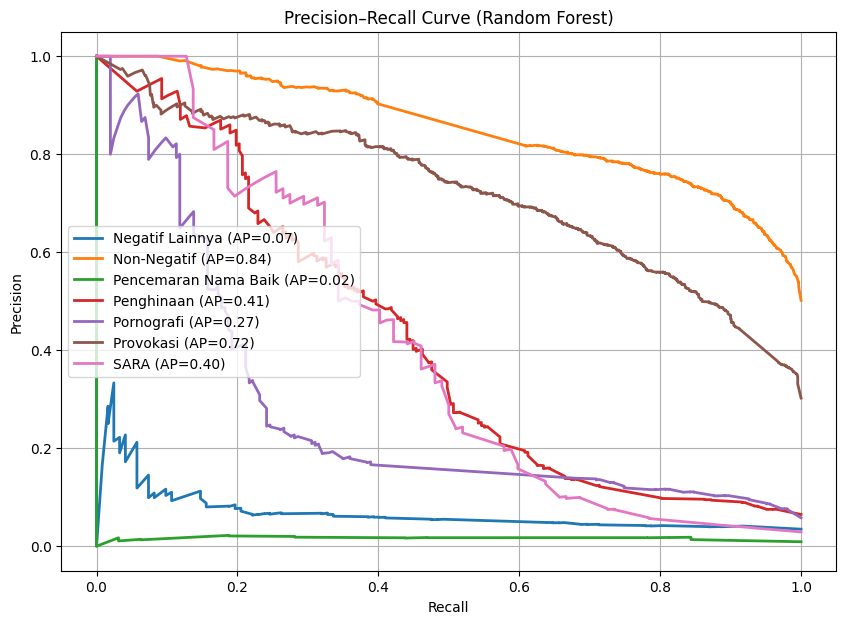

In [62]:
plt.figure(figsize=(10, 7))

for i, label in enumerate(classes):
    plt.plot(
        recall[i],
        precision[i],
        lw=2,
        label=f"{label} (AP={average_precision[i]:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Random Forest)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### Word2Vec & RF - Tuning

In [63]:
rf = RandomForestClassifier(n_estimators=200,
    class_weight='balanced')

rf.fit(x_train_w2v, y_train_stanza)
y_pred = rf.predict(x_test_w2v)

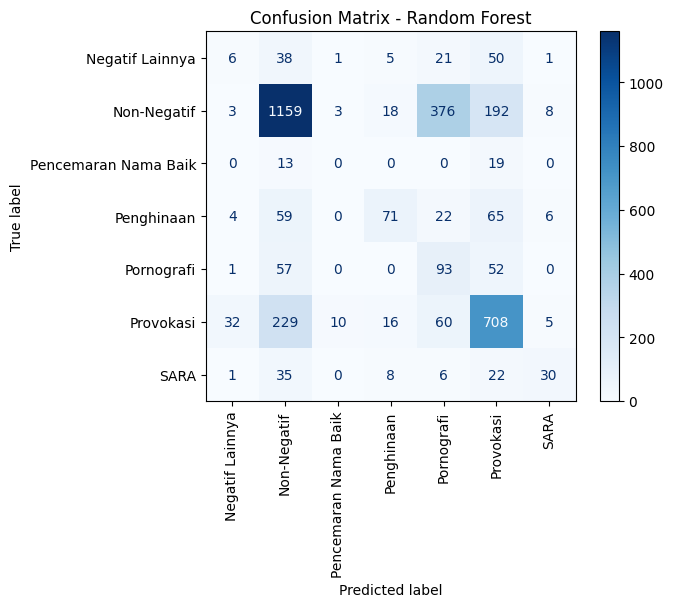

In [64]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_stanza,
    y_pred,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest")
plt.xticks(rotation=90)
plt.show()

In [65]:
print('\nClassification Report Random Forest\n')
print(classification_report(y_test_stanza, y_pred, target_names=RF_lable))


Classification Report Random Forest

                      precision    recall  f1-score   support

     Negatif Lainnya       0.13      0.05      0.07       122
         Non-Negatif       0.73      0.66      0.69      1759
Pencemaran Nama Baik       0.00      0.00      0.00        32
          Penghinaan       0.60      0.31      0.41       227
          Pornografi       0.16      0.46      0.24       203
           Provokasi       0.64      0.67      0.65      1060
                SARA       0.60      0.29      0.39       102

            accuracy                           0.59      3505
           macro avg       0.41      0.35      0.35      3505
        weighted avg       0.63      0.59      0.60      3505



In [66]:
y_score = rf.predict_proba(x_test_w2v)

In [67]:
precision = {}
recall = {}
average_precision = {}

for i in range(len(classes)):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )
    average_precision[i] = average_precision_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

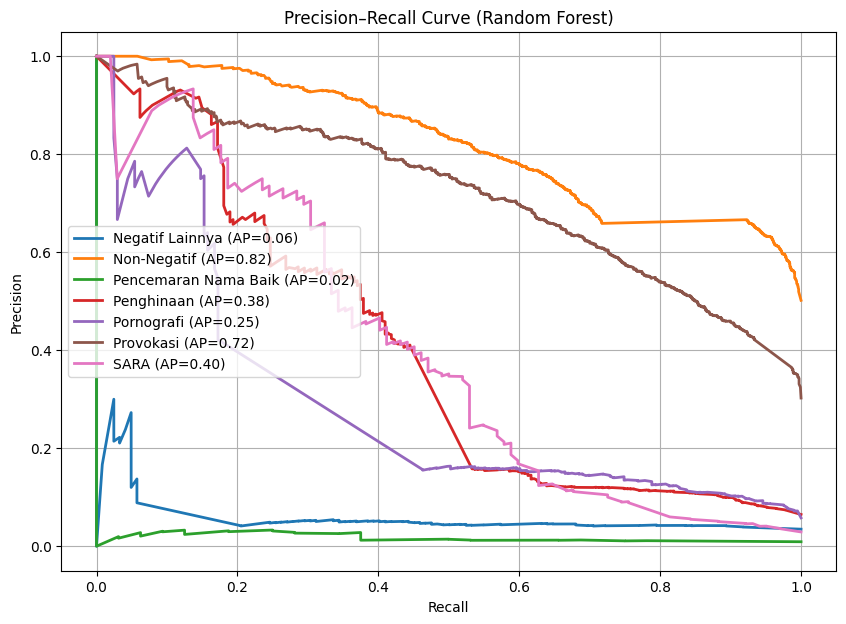

In [68]:
plt.figure(figsize=(10, 7))

for i, label in enumerate(classes):
    plt.plot(
        recall[i],
        precision[i],
        lw=2,
        label=f"{label} (AP={average_precision[i]:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Random Forest)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## RANDOM FOREST - 2 STAGE

## TF-IDF & RF - Default

In [69]:
# Stage 1
y_train_stage1 = y_train_stanza.apply(lambda x: "Negatif" if x != "Non-Negatif" else "Non-Negatif")
y_test_stage1 = y_test_stanza.apply(lambda x: "Negatif" if x != "Non-Negatif" else "Non-Negatif")

In [70]:
y_test_stage1.value_counts()

Final Label
Non-Negatif    1759
Negatif        1746
Name: count, dtype: int64

In [71]:
rf_stage1 = RandomForestClassifier()
rf_stage1.fit(train_tfidf, y_train_stage1)

RandomForestClassifier()

In [72]:
test_pred_stage1 = rf_stage1.predict(test_tfidf)

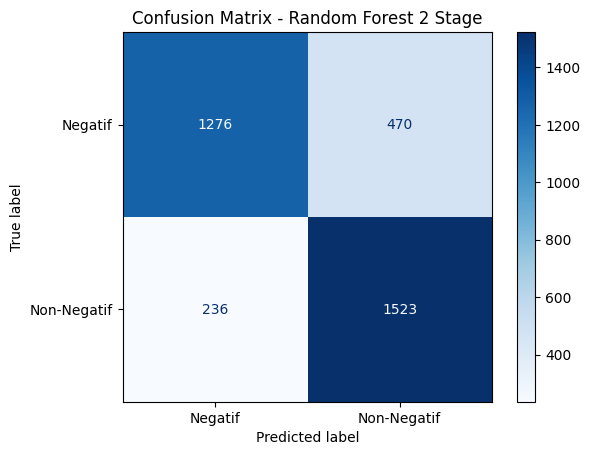

In [73]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_stage1,
    test_pred_stage1,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest 2 Stage")
plt.show()

In [74]:
print("=== Stage 1: Non-Negatif vs Negatif ===")
print(classification_report(y_test_stage1, test_pred_stage1))

=== Stage 1: Non-Negatif vs Negatif ===
              precision    recall  f1-score   support

     Negatif       0.84      0.73      0.78      1746
 Non-Negatif       0.76      0.87      0.81      1759

    accuracy                           0.80      3505
   macro avg       0.80      0.80      0.80      3505
weighted avg       0.80      0.80      0.80      3505



In [75]:
# Stage 2
negative_labels = [
    "Provokasi",
    "Penghinaan",
    "Pencemaran Nama Baik",
    "Pornografi",
    "SARA",
    "Negatif Lainnya"
]

In [76]:
train_tfidf.index = y_train_stanza.index

In [77]:
train_mask_stage2 = y_train_stanza.isin(negative_labels).values

x_train_stage2 = train_tfidf[train_mask_stage2]
y_train_stage2 = y_train_stanza[train_mask_stage2]

In [78]:
test_tfidf.index = y_test_stanza.index

In [79]:
test_mask_stage2 = (
    (test_pred_stage1 == "Negatif") &
    (y_test_stanza.isin(negative_labels))
).values

x_test_stage2 = test_tfidf[test_mask_stage2]
y_test_stage2 = y_test_stanza[test_mask_stage2]

In [80]:
rf_stage2 = RandomForestClassifier()
rf_stage2.fit(x_train_stage2, y_train_stage2)

RandomForestClassifier()

In [81]:
stage2_pred = rf_stage2.predict(x_test_stage2)

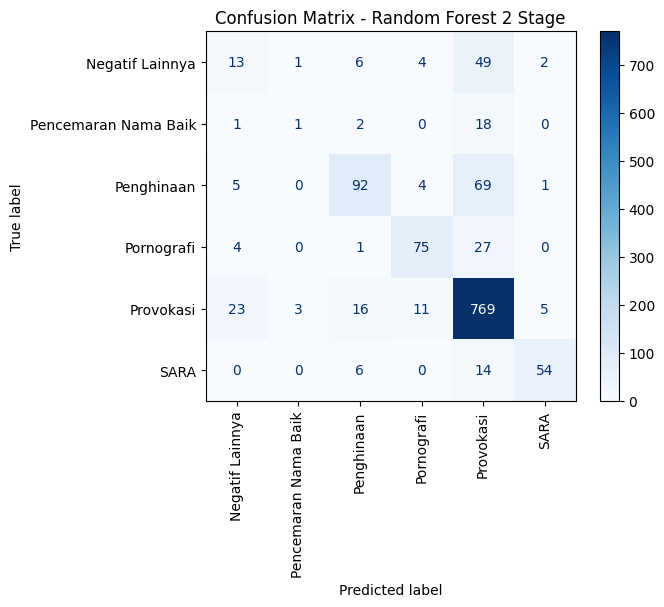

In [82]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_stage2,
    stage2_pred,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest 2 Stage")
plt.xticks(rotation=90)
plt.show()

In [83]:
print("\n=== Stage 2: Kategori Spesifik untuk Komentar Negatif ===")
print(classification_report(y_test_stage2, stage2_pred))


=== Stage 2: Kategori Spesifik untuk Komentar Negatif ===
                      precision    recall  f1-score   support

     Negatif Lainnya       0.28      0.17      0.21        75
Pencemaran Nama Baik       0.20      0.05      0.07        22
          Penghinaan       0.75      0.54      0.63       171
          Pornografi       0.80      0.70      0.75       107
           Provokasi       0.81      0.93      0.87       827
                SARA       0.87      0.73      0.79        74

            accuracy                           0.79      1276
           macro avg       0.62      0.52      0.55      1276
        weighted avg       0.76      0.79      0.77      1276



In [84]:
import time

start = time.time()

# Stage 1
test_pred_stage1 = rf_stage1.predict(test_tfidf)

# Stage 2
stage2_pred = rf_stage2.predict(x_test_stage2)

end = time.time()

total_time = end - start
num_samples = test_tfidf.shape[0]

time_per_sample = total_time / num_samples

print("Total Inference Time:", total_time, "seconds")
print("Inference Time per Sample:", time_per_sample, "seconds")
print("Inference Time per Sample:", time_per_sample * 1000, "ms")

Total Inference Time: 1.4696457386016846 seconds
Inference Time per Sample: 0.00041929978276795564 seconds
Inference Time per Sample: 0.41929978276795565 ms


In [85]:
final_pred = pd.Series(
    data=test_pred_stage1,
    index=y_test_stanza.index
)

final_pred.loc[test_mask_stage2] = stage2_pred

In [86]:
final_labels = [
    "Non-Negatif",
    "Negatif Lainnya",
    "Pencemaran Nama Baik",
    "Penghinaan",
    "Pornografi",
    "Provokasi",
    "SARA"
]

print("\n=== FINAL REPORT ===")
print(classification_report(
    y_test_stanza,
    final_pred,
    labels=final_labels
))


=== FINAL REPORT ===
                      precision    recall  f1-score   support

         Non-Negatif       0.76      0.87      0.81      1759
     Negatif Lainnya       0.28      0.11      0.15       122
Pencemaran Nama Baik       0.20      0.03      0.05        32
          Penghinaan       0.75      0.41      0.53       227
          Pornografi       0.80      0.37      0.51       203
           Provokasi       0.81      0.73      0.77      1060
                SARA       0.87      0.53      0.66       102

           micro avg       0.77      0.72      0.75      3505
           macro avg       0.64      0.43      0.50      3505
        weighted avg       0.76      0.72      0.73      3505



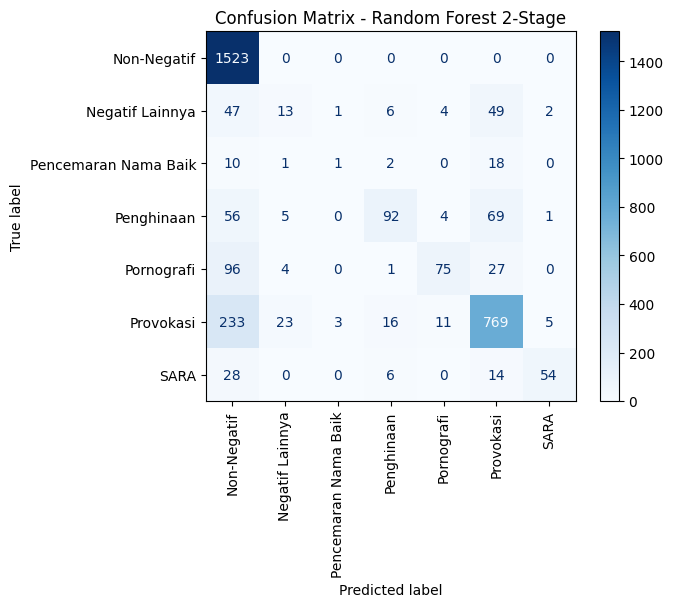

In [87]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_stanza,
    final_pred,
    labels=final_labels,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest 2-Stage")
plt.xticks(rotation=90)
plt.show()

## Word2Vec & RF - Default

In [88]:
# Stage 1
y_train_stage1 = y_train_stanza.apply(lambda x: "Negatif" if x != "Non-Negatif" else "Non-Negatif")
y_test_stage1 = y_test_stanza.apply(lambda x: "Negatif" if x != "Non-Negatif" else "Non-Negatif")

In [89]:
x_train_tokens_s1 = [x.split() for x in x_train_stanza]
x_test_tokens_s1  = [x.split() for x in x_test_stanza]

In [90]:
from gensim.models import Word2Vec

w2v_stage1 = Word2Vec(
    sentences=x_train_tokens_s1,
    vector_size=100,   # dimensi embedding
    window=5,
    min_count=2,
    workers=4,
    sg=1              # 1 = skip-gram (umumnya lebih bagus)
)

In [91]:
x_train_w2v_s1 = np.array([
    document_vector(doc, w2v_stage1)
    for doc in x_train_tokens_s1
])

x_test_w2v_s1 = np.array([
    document_vector(doc, w2v_stage1)
    for doc in x_test_tokens_s1
])


In [92]:
rf_stage1 = RandomForestClassifier(
)

rf_stage1.fit(x_train_w2v_s1, y_train_stage1)

RandomForestClassifier()

In [93]:
y_pred_s1 = rf_stage1.predict(x_test_w2v_s1)

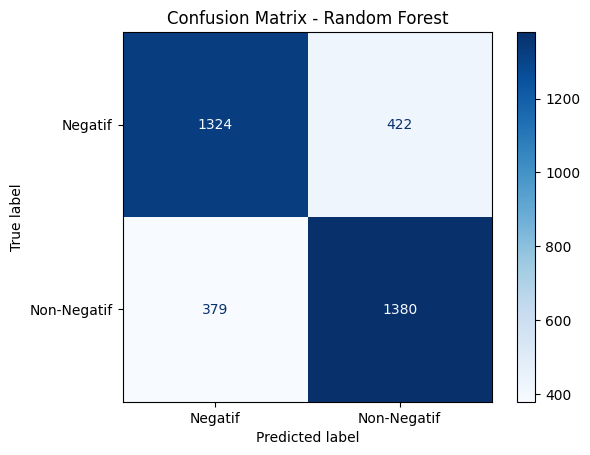

In [94]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_stage1,
    y_pred_s1,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [95]:
print("\n=== Stage 1: Non-Negatif vs Negatif ===")
print(classification_report(y_test_stage1, y_pred_s1))


=== Stage 1: Non-Negatif vs Negatif ===
              precision    recall  f1-score   support

     Negatif       0.78      0.76      0.77      1746
 Non-Negatif       0.77      0.78      0.78      1759

    accuracy                           0.77      3505
   macro avg       0.77      0.77      0.77      3505
weighted avg       0.77      0.77      0.77      3505



In [96]:
# Stage 2
negative_labels = [
    "Provokasi",
    "Penghinaan",
    "Pencemaran Nama Baik",
    "Pornografi",
    "SARA",
    "Negatif Lainnya"
]

In [97]:
train_mask_stage2 = y_train_stanza.isin(negative_labels).values

x_train_tokens_s2 = [
    x_train_tokens_s1[i]
    for i in range(len(x_train_tokens_s1))
    if train_mask_stage2[i]
]

y_train_stage2 = y_train_stanza[train_mask_stage2]

In [98]:
w2v_stage2 = Word2Vec(
    sentences=x_train_tokens_s2,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

# Convert train ke vector
x_train_w2v_s2 = np.array([
    document_vector(doc, w2v_stage2)
    for doc in x_train_tokens_s2
])

In [99]:
test_mask_stage2 = (
    (y_pred_s1 == "Negatif") &
    (y_test_stanza.isin(negative_labels))
).values

x_test_tokens_s2 = [
    x_test_tokens_s1[i]
    for i in range(len(x_test_tokens_s1))
    if test_mask_stage2[i]
]

In [100]:
y_test_stage2 = y_test_stanza[test_mask_stage2]

In [101]:
x_test_w2v_s2 = np.array([
    document_vector(doc, w2v_stage2)
    for doc in x_test_tokens_s2
])

In [102]:
rf_stage2 = RandomForestClassifier(random_state=42)
rf_stage2.fit(x_train_w2v_s2, y_train_stage2)

stage2_pred = rf_stage2.predict(x_test_w2v_s2)

In [103]:
print("\n=== STAGE 2: Kategori Spesifik Negatif ===")
print(classification_report(y_test_stage2, stage2_pred))


=== STAGE 2: Kategori Spesifik Negatif ===
                      precision    recall  f1-score   support

     Negatif Lainnya       0.30      0.10      0.15        78
Pencemaran Nama Baik       0.00      0.00      0.00        25
          Penghinaan       0.75      0.32      0.45       177
          Pornografi       0.70      0.30      0.42       107
           Provokasi       0.73      0.96      0.82       858
                SARA       0.73      0.41      0.52        79

            accuracy                           0.72      1324
           macro avg       0.53      0.35      0.39      1324
        weighted avg       0.69      0.72      0.67      1324



In [104]:
final_pred = pd.Series(
    data=y_pred_s1,
    index=y_test_stanza.index
)

# Replace yang negatif dengan hasil Stage 2
final_pred.loc[test_mask_stage2] = stage2_pred

final_labels = [
    "Non-Negatif",
    "Negatif Lainnya",
    "Pencemaran Nama Baik",
    "Penghinaan",
    "Pornografi",
    "Provokasi",
    "SARA"
]

In [105]:
print("\n=== FINAL REPORT WORD2VEC 2-STAGE ===")
print(classification_report(
    y_test_stanza,
    final_pred,
    labels=final_labels
))


=== FINAL REPORT WORD2VEC 2-STAGE ===
                      precision    recall  f1-score   support

         Non-Negatif       0.77      0.78      0.78      1759
     Negatif Lainnya       0.30      0.07      0.11       122
Pencemaran Nama Baik       0.00      0.00      0.00        32
          Penghinaan       0.75      0.25      0.38       227
          Pornografi       0.70      0.16      0.26       203
           Provokasi       0.73      0.77      0.75      1060
                SARA       0.73      0.31      0.44       102

           micro avg       0.75      0.66      0.70      3505
           macro avg       0.57      0.34      0.39      3505
        weighted avg       0.72      0.66      0.67      3505



## Augmented Data

In [106]:
augmented_df = pd.read_csv("/kaggle/input/datasets/jessicaliviana/augmented/augmented.csv")

In [107]:
augmented_df.head()

,clean_text,label_stage2,label_stage1,augmented
0,PERDAMAIAN GRAGAS,4,1,True
1,hama codeblue,4,1,True
2,"Makan sepanjang waktu, seperti Ooops.",4,1,True
3,"Persetan denganmu, bung.",4,1,True
4,HAMA PAIN TEMPLE,4,1,True


In [108]:
toxic_labels = [
    "Pornografi",
    "Pencemaran Nama Baik",
    "Provokasi",
    "SARA",
    "Penghinaan",
    "Negatif Lainnya"
]

id2label_s2 = {i: name for i, name in enumerate(toxic_labels)}

In [109]:
augmented_df["Final Label"] = augmented_df["label_stage2"].map(id2label_s2)

In [110]:
x_train_aug = augmented_df["clean_text"]
y_train_aug = augmented_df["Final Label"]

x_train_final = pd.concat(
    [x_train_stanza, x_train_aug],
    ignore_index=True
)

y_train_final = pd.concat(
    [y_train_stanza, y_train_aug],
    ignore_index=True
)

In [111]:
x_test_final = x_test_stanza
y_test_final = y_test_stanza

In [112]:
print("Before Augmentation:")
print(y_train_stanza.value_counts())

print("\nAfter Augmentation:")
print(y_train_final.value_counts())

Before Augmentation:
Final Label
Non-Negatif             7036
Provokasi               4242
Penghinaan               908
Pornografi               811
Negatif Lainnya          487
SARA                     409
Pencemaran Nama Baik     126
Name: count, dtype: int64

After Augmentation:
Final Label
Non-Negatif             7036
Provokasi               4242
Penghinaan              1657
Pornografi              1478
Negatif Lainnya          892
SARA                     782
Pencemaran Nama Baik     247
Name: count, dtype: int64


In [113]:
print(y_test_final.value_counts())

Final Label
Non-Negatif             1759
Provokasi               1060
Penghinaan               227
Pornografi               203
Negatif Lainnya          122
SARA                     102
Pencemaran Nama Baik      32
Name: count, dtype: int64


In [114]:
x_train_final

0                                                     cina
1                                             cantik agnes
2                                      ridho semangat niki
3                                            marasa aku😭😭😢
4        niki mahh vibes positif biarpun amarah ledak a...
                               ...                        
16329                                Wajah membenci Tuhan.
16330       Ingin melihat orang ini masuk untuk tahun ini.
16331              Ini bukan untuk apa-apa untuk menjilat.
16332    Semuanya tipuan dari awal tipuan willie juga s...
16333                       Ini tidak layak sebuah contoh.
Length: 16334, dtype: object

## TF-IDF & RF - Default (1 Stage)

In [115]:
vectorizer = TfidfVectorizer()
train_tfidf= vectorizer.fit_transform(x_train_final)
test_tfidf = vectorizer.transform(x_test_final)

In [116]:
TFIDF_train=pd.DataFrame(train_tfidf.toarray(),columns=vectorizer.get_feature_names_out())
TFIDF_train.head()

,aacchh,aah,aahh,aal,aamii,aamiim,aamiin,aamiinn,aamin,aammiin,...,𝙢𝙪𝙙𝙞𝙠,𝙥𝙞𝙣𝙟𝙚𝙢,𝙪𝙖𝙣𝙜,𝚂𝚊𝚔𝚒𝚗𝚐,𝚋𝚊𝚓𝚞,𝚌𝚊𝚙𝚎,𝚕𝚞𝚙𝚊,𝚙𝚊𝚔𝚎,𝚚𝚒𝚖,𝚜𝚊𝚖𝚙𝚎
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [117]:
TFIDF_test = pd.DataFrame(test_tfidf.toarray(),columns=vectorizer.get_feature_names_out())
TFIDF_test.head()

,aacchh,aah,aahh,aal,aamii,aamiim,aamiin,aamiinn,aamin,aammiin,...,𝙢𝙪𝙙𝙞𝙠,𝙥𝙞𝙣𝙟𝙚𝙢,𝙪𝙖𝙣𝙜,𝚂𝚊𝚔𝚒𝚗𝚐,𝚋𝚊𝚓𝚞,𝚌𝚊𝚙𝚎,𝚕𝚞𝚙𝚊,𝚙𝚊𝚔𝚎,𝚚𝚒𝚖,𝚜𝚊𝚖𝚙𝚎
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [118]:
from sklearn.ensemble import RandomForestClassifier
RF_Class = RandomForestClassifier()
RF_Class.fit(train_tfidf, y_train_final)

RandomForestClassifier()

In [119]:
test_rf_class = RF_Class.predict(test_tfidf)

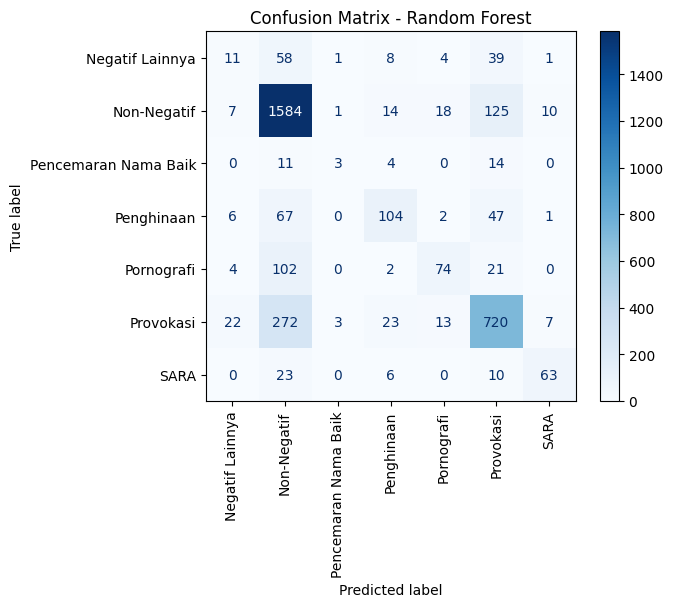

In [120]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    test_rf_class,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest")
plt.xticks(rotation=90)
plt.show()

In [121]:
print('\nClassification Report Random Forest\n')
print(classification_report(y_test_final, test_rf_class, target_names=RF_lable))


Classification Report Random Forest

                      precision    recall  f1-score   support

     Negatif Lainnya       0.22      0.09      0.13       122
         Non-Negatif       0.75      0.90      0.82      1759
Pencemaran Nama Baik       0.38      0.09      0.15        32
          Penghinaan       0.65      0.46      0.54       227
          Pornografi       0.67      0.36      0.47       203
           Provokasi       0.74      0.68      0.71      1060
                SARA       0.77      0.62      0.68       102

            accuracy                           0.73      3505
           macro avg       0.59      0.46      0.50      3505
        weighted avg       0.71      0.73      0.71      3505



## TF-IDF & RF - Default (2 Stage)

In [122]:
# Stage 1
y_train_stage1 = y_train_final.apply(lambda x: "Negatif" if x != "Non-Negatif" else "Non-Negatif")
y_test_stage1 = y_test_final.apply(lambda x: "Negatif" if x != "Non-Negatif" else "Non-Negatif")

In [123]:
y_test_stage1.value_counts()

Final Label
Non-Negatif    1759
Negatif        1746
Name: count, dtype: int64

In [124]:
rf_stage1 = RandomForestClassifier()
rf_stage1.fit(train_tfidf, y_train_stage1)

RandomForestClassifier()

In [125]:
test_pred_stage1 = rf_stage1.predict(test_tfidf)

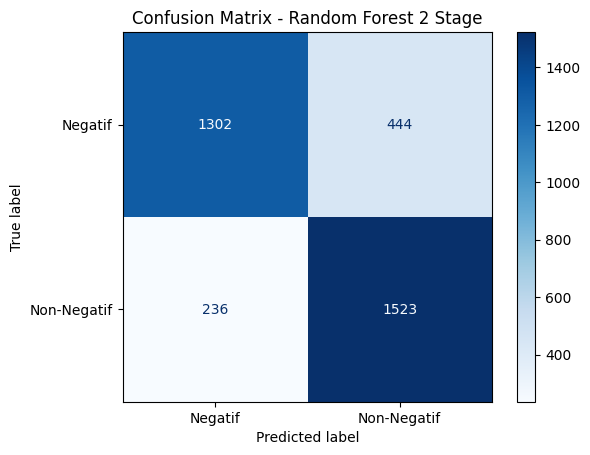

In [126]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_stage1,
    test_pred_stage1,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest 2 Stage")
plt.show()

In [127]:
print("=== Stage 1: Non-Negatif vs Negatif ===")
print(classification_report(y_test_stage1, test_pred_stage1))

=== Stage 1: Non-Negatif vs Negatif ===
              precision    recall  f1-score   support

     Negatif       0.85      0.75      0.79      1746
 Non-Negatif       0.77      0.87      0.82      1759

    accuracy                           0.81      3505
   macro avg       0.81      0.81      0.81      3505
weighted avg       0.81      0.81      0.81      3505



In [128]:
# Stage 2
negative_labels = [
    "Provokasi",
    "Penghinaan",
    "Pencemaran Nama Baik",
    "Pornografi",
    "SARA",
    "Negatif Lainnya"
]

In [129]:
train_tfidf.index = y_train_final.index

In [130]:
train_mask_stage2 = y_train_final.isin(negative_labels).values

x_train_stage2 = train_tfidf[train_mask_stage2]
y_train_stage2 = y_train_final[train_mask_stage2]

In [131]:
test_tfidf.index = y_test_stanza.index

In [132]:
test_mask_stage2 = (
    (test_pred_stage1 == "Negatif") &
    (y_test_stanza.isin(negative_labels))
).values

x_test_stage2 = test_tfidf[test_mask_stage2]
y_test_stage2 = y_test_stanza[test_mask_stage2]

In [133]:
rf_stage2 = RandomForestClassifier()
rf_stage2.fit(x_train_stage2, y_train_stage2)

RandomForestClassifier()

In [134]:
stage2_pred = rf_stage2.predict(x_test_stage2)

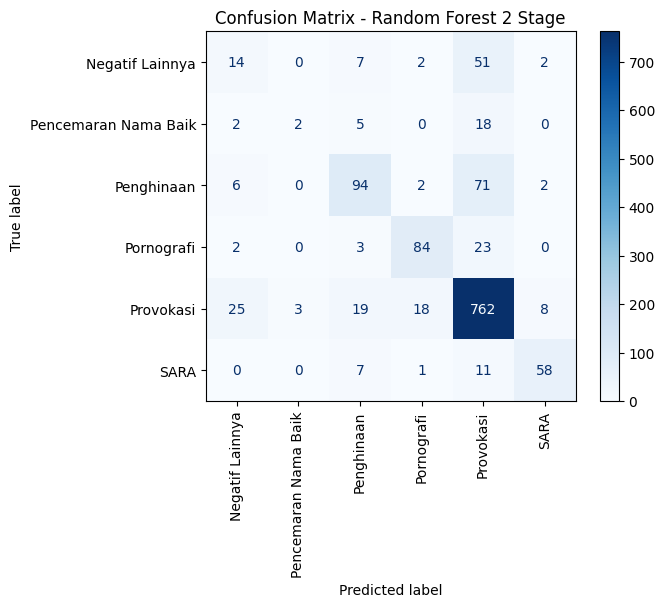

In [135]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_stage2,
    stage2_pred,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Random Forest 2 Stage")
plt.xticks(rotation=90)
plt.show()

In [136]:
print("\n=== Stage 2: Kategori Spesifik untuk Komentar Negatif ===")
print(classification_report(y_test_stage2, stage2_pred))


=== Stage 2: Kategori Spesifik untuk Komentar Negatif ===
                      precision    recall  f1-score   support

     Negatif Lainnya       0.29      0.18      0.22        76
Pencemaran Nama Baik       0.40      0.07      0.12        27
          Penghinaan       0.70      0.54      0.61       175
          Pornografi       0.79      0.75      0.77       112
           Provokasi       0.81      0.91      0.86       835
                SARA       0.83      0.75      0.79        77

            accuracy                           0.78      1302
           macro avg       0.63      0.54      0.56      1302
        weighted avg       0.76      0.78      0.76      1302



In [137]:
final_pred = pd.Series(
    data=test_pred_stage1,
    index=y_test_final.index
)

final_pred.loc[test_mask_stage2] = stage2_pred

In [138]:
final_labels = [
    "Non-Negatif",
    "Negatif Lainnya",
    "Pencemaran Nama Baik",
    "Penghinaan",
    "Pornografi",
    "Provokasi",
    "SARA"
]

print("\n=== FINAL REPORT ===")
print(classification_report(
    y_test_final,
    final_pred,
    labels=final_labels
))


=== FINAL REPORT ===
                      precision    recall  f1-score   support

         Non-Negatif       0.77      0.87      0.82      1759
     Negatif Lainnya       0.29      0.11      0.16       122
Pencemaran Nama Baik       0.40      0.06      0.11        32
          Penghinaan       0.70      0.41      0.52       227
          Pornografi       0.79      0.41      0.54       203
           Provokasi       0.81      0.72      0.76      1060
                SARA       0.83      0.57      0.67       102

           micro avg       0.78      0.72      0.75      3505
           macro avg       0.65      0.45      0.51      3505
        weighted avg       0.76      0.72      0.73      3505

